# 09 — ConvLSTM Spatial-Temporal Modeling

**Project:** Spatio-temporal wildfire activity prediction in Kalimantan  
**Role in pipeline:** Alternative spatial-temporal deep-learning experiment after the tabular benchmark.

### Objective

The main benchmark in Notebook 05 represents each cell-day as a tabular observation. This notebook changes the representation by arranging the 272 Kalimantan grid cells into their native **17 × 16 spatial grid** and feeding a sequence of consecutive days to a ConvLSTM model.

The experiment asks whether explicitly modeling **local spatial structure and temporal dynamics jointly** improves the predictive performance obtained by the 20-feature tabular benchmark.

### Input representation

```text
20 engineered features
        ↓
17 × 16 spatial grid
        ↓
14 consecutive days
        ↓
ConvLSTM2D
        ↓
17 × 16 next-day fire-activity probability map
```

The target remains `target_fire_active_t1`.

> **Important:** This is an alternative representation experiment. It is not combined with the spatial-lag features from Notebook 06.


In [2]:
# 1. Imports and reproducibility

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


In [3]:
# 2. Project paths and input

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSED_DIR / "karhut_ml_dataset_kalimantan.csv"

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input dataset not found: {INPUT_FILE}")

df = pd.read_csv(INPUT_FILE)
df["date"] = pd.to_datetime(df["date"])

print("Input:", INPUT_FILE)
print("Shape:", df.shape)
print("Date:", df["date"].min().date(), "→", df["date"].max().date())
print("Cells:", df["cell_id"].nunique())


Input: c:\Users\Asus\Documents\skripsi-karhut\data\processed\karhut_ml_dataset_kalimantan.csv
Shape: (34272, 29)
Date: 2026-05-08 → 2026-09-10
Cells: 272


In [4]:
# 3. Exact 20-feature definition shared with Notebook 05

FEATURES = [
    # Fire History (10)
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7",

    # Weather (10)
    "temperature_mean",
    "temperature_max",
    "relative_humidity_mean",
    "precipitation_sum",
    "boundary_layer_height_mean",
    "vapour_pressure_deficit_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_u_mean",
    "wind_v_mean"
]

TARGET = "target_fire_active_t1"

required = (
    ["region", "cell_id", "date", "grid_lat", "grid_lon", TARGET]
    + FEATURES
)

missing = sorted(set(required) - set(df.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

if len(FEATURES) != 20:
    raise AssertionError("The benchmark must contain exactly 20 features.")

print("Number of features:", len(FEATURES))


Number of features: 20


## 4. Spatial-grid validation

The Kalimantan fire grid produced by Notebook 03 is expected to contain:

- 17 unique latitude positions
- 16 unique longitude positions
- 272 cells in total

The grid is reconstructed from the explicit `grid_lat` and `grid_lon` columns. The notebook does **not** parse coordinates from `cell_id`.


In [5]:
# 4. Validate the 17 × 16 grid

lat_values = np.sort(df["grid_lat"].unique())
lon_values = np.sort(df["grid_lon"].unique())

print("Unique latitudes:", len(lat_values))
print("Unique longitudes:", len(lon_values))
print("Expected cells:", len(lat_values) * len(lon_values))
print("Observed cells:", df[["grid_lat", "grid_lon"]].drop_duplicates().shape[0])

if len(lat_values) != 17 or len(lon_values) != 16:
    raise ValueError(
        f"Unexpected grid dimensions: {len(lat_values)} × {len(lon_values)}"
    )

if df[["grid_lat", "grid_lon"]].drop_duplicates().shape[0] != 272:
    raise ValueError("Expected exactly 272 spatial cells.")

lat_to_i = {lat: i for i, lat in enumerate(lat_values)}
lon_to_j = {lon: j for j, lon in enumerate(lon_values)}

print("Grid validated: 17 × 16 = 272 cells.")


Unique latitudes: 17
Unique longitudes: 16
Expected cells: 272
Observed cells: 272
Grid validated: 17 × 16 = 272 cells.


## 5. Temporal completeness check

ConvLSTM requires a genuine daily sequence. A missing date must not be silently treated as if it were the next day.

The model therefore requires every spatial cell to have one observation for every date in the modeling period.


In [6]:
# 5. Validate one complete daily record per cell

cell_date_duplicates = df.duplicated(["cell_id", "date"]).sum()
if cell_date_duplicates:
    raise ValueError(f"Duplicate cell-date rows: {cell_date_duplicates}")

expected_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
expected_pairs = len(expected_dates) * 272

print("Expected cell-date observations:", expected_pairs)
print("Actual observations:", len(df))

if len(df) != expected_pairs:
    raise ValueError(
        "The dataset is not a complete 272-cell daily panel. "
        "Do not create ConvLSTM sequences until the panel is complete."
    )

missing_pairs = (
    pd.MultiIndex.from_product(
        [expected_dates, df["cell_id"].unique()],
        names=["date", "cell_id"]
    )
    .difference(
        pd.MultiIndex.from_frame(df[["date", "cell_id"]])
    )
)

print("Missing cell-date pairs:", len(missing_pairs))


Expected cell-date observations: 34272
Actual observations: 34272
Missing cell-date pairs: 0


In [7]:
# 6. Build daily spatial grids

df = df.sort_values(["date", "grid_lat", "grid_lon"]).reset_index(drop=True)

dates = np.sort(df["date"].unique())
n_dates = len(dates)
n_lat = len(lat_values)
n_lon = len(lon_values)
n_features = len(FEATURES)

X_grid = np.empty((n_dates, n_lat, n_lon, n_features), dtype=np.float32)
Y_grid = np.empty((n_dates, n_lat, n_lon), dtype=np.float32)

date_to_i = {pd.Timestamp(d): i for i, d in enumerate(dates)}

for row in df.itertuples(index=False):
    di = date_to_i[pd.Timestamp(row.date)]
    li = lat_to_i[row.grid_lat]
    lj = lon_to_j[row.grid_lon]

    X_grid[di, li, lj, :] = np.asarray(
        [getattr(row, feature) for feature in FEATURES],
        dtype=np.float32
    )
    Y_grid[di, li, lj] = float(getattr(row, TARGET))

print("X_grid:", X_grid.shape)
print("Y_grid:", Y_grid.shape)


X_grid: (126, 17, 16, 20)
Y_grid: (126, 17, 16)


## 7. Construct 14-day sequences

For each target day `t`, the model receives the previous 14 days:

```text
[t-14, ..., t-2, t-1] → target at t
```

Thus the first possible target is 14 days after the first modeling date.

The sequence target is a complete **17 × 16 next-day fire-activity map**.


In [8]:
# 7. Create 14-day spatial-temporal sequences

SEQ_LEN = 14

X_seq = []
Y_seq = []
seq_dates = []

for i in range(SEQ_LEN, n_dates):
    X_seq.append(X_grid[i-SEQ_LEN:i])
    Y_seq.append(Y_grid[i])
    seq_dates.append(pd.Timestamp(dates[i]))

X_seq = np.asarray(X_seq, dtype=np.float32)
Y_seq = np.asarray(Y_seq, dtype=np.float32)
seq_dates = np.asarray(seq_dates, dtype="datetime64[ns]")

print("X_seq:", X_seq.shape)
print("Y_seq:", Y_seq.shape)
print("First target date:", pd.Timestamp(seq_dates[0]).date())
print("Last target date:", pd.Timestamp(seq_dates[-1]).date())


X_seq: (112, 14, 17, 16, 20)
Y_seq: (112, 17, 16)
First target date: 2026-05-22
Last target date: 2026-09-10


In [9]:
# 8. Temporal split — same calendar boundaries as Notebook 05

train_mask = seq_dates < np.datetime64("2026-08-01")
val_mask = (
    (seq_dates >= np.datetime64("2026-08-01")) &
    (seq_dates < np.datetime64("2026-09-01"))
)
test_mask = seq_dates >= np.datetime64("2026-09-01")

X_train = X_seq[train_mask]
Y_train = Y_seq[train_mask]

X_val = X_seq[val_mask]
Y_val = Y_seq[val_mask]

X_test = X_seq[test_mask]
Y_test = Y_seq[test_mask]

print("TRAIN:", X_train.shape, Y_train.shape)
print("VALIDATION:", X_val.shape, Y_val.shape)
print("TEST:", X_test.shape, Y_test.shape)

print("\nPositive rates:")
print("Train:", Y_train.mean())
print("Validation:", Y_val.mean())
print("Test:", Y_test.mean())


TRAIN: (71, 14, 17, 16, 20) (71, 17, 16)
VALIDATION: (31, 14, 17, 16, 20) (31, 17, 16)
TEST: (10, 14, 17, 16, 20) (10, 17, 16)

Positive rates:
Train: 0.11899337
Validation: 0.33918408
Test: 0.3194853


## 9. Leakage-safe feature scaling

Neural networks can benefit from standardized inputs. Scaling parameters are fitted **only on the training observations** and then applied unchanged to validation and test data.

The spatial and temporal dimensions are flattened temporarily only for fitting the scaler.


In [10]:
# 9. Fit StandardScaler on training data only

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_val_2d = X_val.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape).astype(np.float32)
X_val_scaled = scaler.transform(X_val_2d).reshape(X_val.shape).astype(np.float32)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape).astype(np.float32)

print("Scaler fitted on training data only.")


Scaler fitted on training data only.


## 10. ConvLSTM architecture

The model uses:

1. `ConvLSTM2D` to learn temporal patterns while preserving local spatial structure.
2. `BatchNormalization` for training stability.
3. `Conv2D(1×1)` to produce one probability per grid cell.

The output is therefore a spatial fire-activity probability map for the next day.


In [11]:
# 10. Define the ConvLSTM model

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model = Sequential([
    Input(shape=(SEQ_LEN, n_lat, n_lon, n_features)),

    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False
    ),

    BatchNormalization(),

    Conv2D(
        filters=1,
        kernel_size=(1, 1),
        activation="sigmoid",
        padding="same"
    )
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 17, 16, 32)     │        60,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 17, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 17, 16, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,193 (235.13 KB)

 Trainable params: 60,129 (234.88 KB)

 Non-trainable params: 64 (256.00 B)

In [12]:
# 11. Weighted binary cross-entropy

n_positive = np.sum(Y_train == 1)
n_negative = np.sum(Y_train == 0)

pos_weight = n_negative / n_positive

print("Training negative pixels:", n_negative)
print("Training positive pixels:", n_positive)
print("Positive weight:", pos_weight)

def weighted_binary_crossentropy(y_true, y_pred):
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

    loss = -(
        pos_weight * y_true * tf.math.log(y_pred)
        + (1.0 - y_true) * tf.math.log(1.0 - y_pred)
    )

    return tf.reduce_mean(loss)


Training negative pixels: 17014
Training positive pixels: 2298
Positive weight: 7.403829416884247


In [13]:
# 12. Compile

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=weighted_binary_crossentropy,
    metrics=[
        tf.keras.metrics.AUC(
            curve="PR",
            name="pr_auc"
        )
    ]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=7,
    restore_best_weights=True
)


In [14]:
# 13. Train

history = model.fit(
    X_train_scaled,
    Y_train[..., np.newaxis],
    validation_data=(
        X_val_scaled,
        Y_val[..., np.newaxis]
    ),
    epochs=50,
    batch_size=8,
    callbacks=[early_stopping],
    verbose=1
)

best_epoch = int(np.argmax(history.history["val_pr_auc"]) + 1)
best_val_pr_auc = float(max(history.history["val_pr_auc"]))

print("Best epoch:", best_epoch)
print("Best validation PR-AUC:", best_val_pr_auc)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.9777 - pr_auc: 0.4236 - val_loss: 1.2138 - val_pr_auc: 0.8103
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.8335 - pr_auc: 0.5201 - val_loss: 1.3268 - val_pr_auc: 0.8000
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.7752 - pr_auc: 0.5657 - val_loss: 1.3097 - val_pr_auc: 0.8128
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.7438 - pr_auc: 0.5865 - val_loss: 1.2737 - val_pr_auc: 0.8153
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.7138 - pr_auc: 0.6105 - val_loss: 1.2595 - val_pr_auc: 0.8142
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.6861 - pr_auc: 0.6317 - val_loss: 1.2725 - val_pr_auc: 0.8090
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.6604 - pr_auc: 0.6561 - val_loss: 1.2936 - val_pr_auc: 0.8002
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.6353 - pr_auc: 0.6773 - val_loss: 1.3125 - val_pr_auc: 0.7939
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━

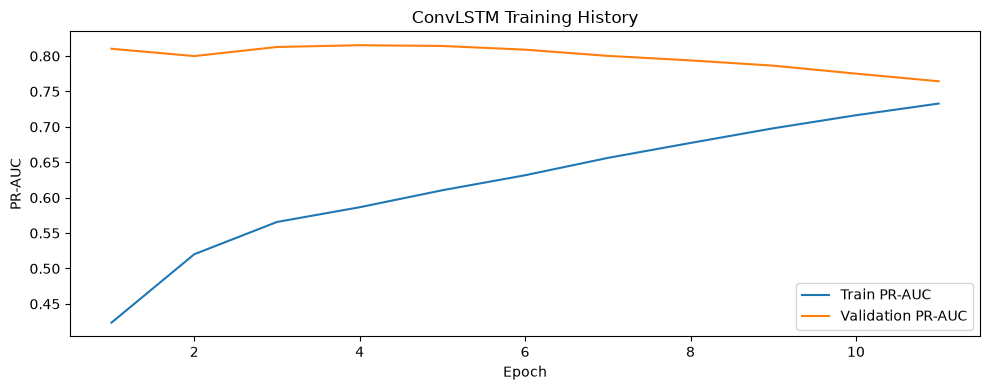

In [15]:
# 14. Plot training history

history_df = pd.DataFrame({
    "epoch": np.arange(1, len(history.history["loss"]) + 1),
    "train_loss": history.history["loss"],
    "val_loss": history.history["val_loss"],
    "train_pr_auc": history.history["pr_auc"],
    "val_pr_auc": history.history["val_pr_auc"]
})

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_pr_auc"], label="Train PR-AUC")
plt.plot(history_df["epoch"], history_df["val_pr_auc"], label="Validation PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("ConvLSTM Training History")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# 15. Validation probability map evaluation

val_proba_map = model.predict(X_val_scaled, verbose=0).squeeze(-1)

y_val_flat = Y_val.reshape(-1).astype(int)
val_proba_flat = val_proba_map.reshape(-1)

val_pr_auc = average_precision_score(y_val_flat, val_proba_flat)

print(f"Validation PR-AUC: {val_pr_auc:.6f}")


Validation PR-AUC: 0.815557


In [17]:
# 16. Select an operating threshold on validation data

thresholds = np.linspace(0.05, 0.95, 181)

threshold_rows = []

for threshold in thresholds:
    pred = (val_proba_flat >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_val_flat, pred, zero_division=0),
        "recall": recall_score(y_val_flat, pred, zero_division=0),
        "f1": f1_score(y_val_flat, pred, zero_division=0),
        "accuracy": accuracy_score(y_val_flat, pred)
    })

threshold_df = pd.DataFrame(threshold_rows)

# F1 is used only to select the operating threshold.
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

OPERATING_THRESHOLD = float(best_threshold_row["threshold"])

print("Selected validation threshold:", OPERATING_THRESHOLD)
print(best_threshold_row)


Selected validation threshold: 0.585
threshold    0.585000
precision    0.726619
recall       0.812238
f1           0.767046
accuracy     0.832661
Name: 107, dtype: float64


In [18]:
# 17. Full validation metrics

val_pred = (
    val_proba_flat >= OPERATING_THRESHOLD
).astype(int)

val_metrics = {
    "Model": "ConvLSTM",
    "Split": "Validation",
    "PR-AUC": val_pr_auc,
    "Precision": precision_score(y_val_flat, val_pred, zero_division=0),
    "Recall": recall_score(y_val_flat, val_pred, zero_division=0),
    "F1": f1_score(y_val_flat, val_pred, zero_division=0),
    "Accuracy": accuracy_score(y_val_flat, val_pred),
    "Threshold": OPERATING_THRESHOLD
}

print(pd.Series(val_metrics).to_string())
print("\nConfusion Matrix:")
print(confusion_matrix(y_val_flat, val_pred))


Model          ConvLSTM
Split        Validation
PR-AUC         0.815557
Precision      0.726619
Recall         0.812238
F1             0.767046
Accuracy       0.832661
Threshold         0.585

Confusion Matrix:
[[4698  874]
 [ 537 2323]]


In [19]:
# 18. Test evaluation — evaluated once after model/threshold selection

test_proba_map = model.predict(X_test_scaled, verbose=0).squeeze(-1)

y_test_flat = Y_test.reshape(-1).astype(int)
test_proba_flat = test_proba_map.reshape(-1)

test_pred = (
    test_proba_flat >= OPERATING_THRESHOLD
).astype(int)

test_metrics = {
    "Model": "ConvLSTM",
    "Split": "Test",
    "PR-AUC": average_precision_score(y_test_flat, test_proba_flat),
    "Precision": precision_score(y_test_flat, test_pred, zero_division=0),
    "Recall": recall_score(y_test_flat, test_pred, zero_division=0),
    "F1": f1_score(y_test_flat, test_pred, zero_division=0),
    "Accuracy": accuracy_score(y_test_flat, test_pred),
    "Threshold": OPERATING_THRESHOLD
}

print(pd.Series(test_metrics).to_string())
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_flat, test_pred))


Model        ConvLSTM
Split            Test
PR-AUC       0.749816
Precision    0.590762
Recall       0.838895
F1           0.693295
Accuracy     0.762868
Threshold       0.585

Confusion Matrix:
[[1346  505]
 [ 140  729]]


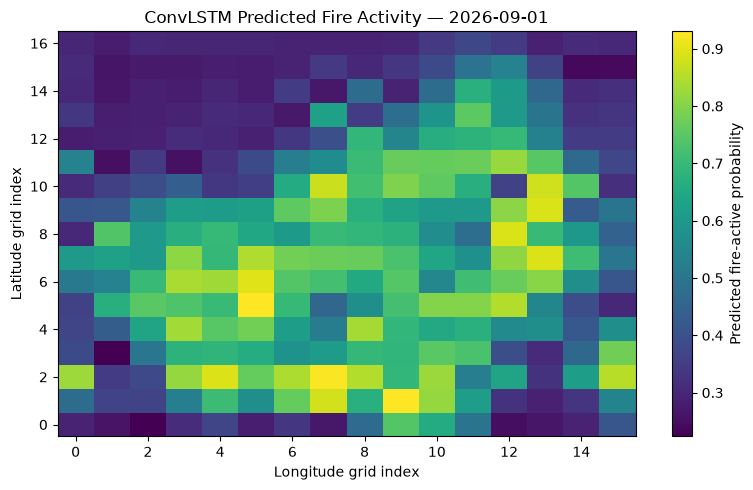

In [20]:
# 19. Example next-day probability map

example_idx = 0

plt.figure(figsize=(8, 5))
plt.imshow(
    test_proba_map[example_idx],
    origin="lower",
    aspect="auto"
)
plt.colorbar(label="Predicted fire-active probability")
plt.xlabel("Longitude grid index")
plt.ylabel("Latitude grid index")
plt.title(
    f"ConvLSTM Predicted Fire Activity — "
    f"{pd.Timestamp(seq_dates[test_mask][example_idx]).date()}"
)
plt.tight_layout()
plt.show()


In [21]:
# 20. Save results

validation_results_df = pd.DataFrame([val_metrics])
test_results_df = pd.DataFrame([test_metrics])

validation_path = RESULTS_DIR / "convlstm_validation_results.csv"
test_path = RESULTS_DIR / "convlstm_test_results.csv"
history_path = RESULTS_DIR / "convlstm_training_history.csv"

validation_results_df.to_csv(validation_path, index=False)
test_results_df.to_csv(test_path, index=False)
history_df.to_csv(history_path, index=False)

print("Saved:")
print(validation_path)
print(test_path)
print(history_path)


Saved:
c:\Users\Asus\Documents\skripsi-karhut\model_results\convlstm_validation_results.csv
c:\Users\Asus\Documents\skripsi-karhut\model_results\convlstm_test_results.csv
c:\Users\Asus\Documents\skripsi-karhut\model_results\convlstm_training_history.csv


## 21. Interpretation

This experiment should be interpreted separately from the tabular benchmark.

The ConvLSTM model receives the same 20 engineered variables used by the main benchmark, but changes their representation into a spatial grid and temporal sequence. Therefore, any performance difference reflects the tested spatial-temporal representation and architecture rather than a different feature set.

The primary comparison remains **PR-AUC**, while threshold-dependent metrics are reported at the validation-selected operating threshold.

A result below the Notebook 05 benchmark does not imply that spatial structure is irrelevant. It means that this particular ConvLSTM configuration and representation did not provide a predictive improvement under the same temporal evaluation protocol.
